## imports 

In [ ]:
import logging
import os

import lightning

from openretina.data_io.base import MoviesTrainTestSplit, ResponsesTrainTestSplit, compute_data_info
from openretina.data_io.base_dataloader import multiple_movies_dataloaders
from openretina.data_io.cyclers import LongCycler, ShortCycler
from openretina.models.core_readout import CoreReadout
from openretina.utils.file_utils import get_cache_directory, get_local_file_path
from openretina.utils.h5_handling import load_dataset_from_h5, load_h5_into_dict
from openretina.utils.misc import CustomPrettyPrinter

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)  # to display logs in jupyter notebooks

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
pp = CustomPrettyPrinter(indent=4, max_lines=40)

## loading necessary tables from data base

In [91]:
import numpy as np
import h5py

In [ ]:

import os
import os
import datajoint as dj
from djimaging.user.ssuhai.schemas.ssuhai_schema import *
from djimaging.utils.dj_utils import activate_schema
import warnings
warnings.simplefilter("ignore", FutureWarning)
username = !whoami
username = username[0]
home_directory = os.path.expanduser("~")
path_to_djimaging = f'{home_directory}/GitRepos'
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'
schema_name = f"ageuler_{username}_test"

# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-04-22 20:49:57,135][INFO]: Connecting ssuhai@172.25.240.200:3306
2025-04-22 20:49:57,135 - INFO - Connecting ssuhai@172.25.240.200:3306
[2025-04-22 20:49:57,183][INFO]: Connected ssuhai@172.25.240.200:3306
2025-04-22 20:49:57,183 - INFO - Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_test


DataJoint connection (connected) ssuhai@172.25.240.200:3306

In [22]:
activate_schema(schema=schema, create_schema=True, create_tables=True)


In [40]:
PreprocessParams().add_default(skip_duplicates=True)
PreprocessParams()

stim_name Unique string identifier,preprocess_id unique param set id,window_length window length for SavGol filter in seconds,poly_order order of polynomial for savgol filter,non_negative Clip negative values of trace,subtract_baseline Subtract baseline,"standardize standardize (1: with sd of baseline, 2: sd of trace, 0: nothing)","f_cutoff Cutoff frequency for low pass filter, only applied when > 0.","fs_resample Resampling frequency, only applied when > 0."
closedloop0,1,60,3,0,1,1,0.0,0.0
closedloop1,1,60,3,0,1,1,0.0,0.0


In [41]:
PreprocessTraces().populate(processes=20, display_progress=True)
PreprocessTraces()

Processes: 100%|██████████| 202/202 [00:01<00:00, 148.41it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,pp_trace preprocessed trace,smoothed_trace output of savgol filter which is subtracted from the raw trace,pp_trace_t0 numerical array of trace times,pp_trace_dt time between frames
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,1,1,=BLOB=,=BLOB=,0.004,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,2,1,=BLOB=,=BLOB=,0.002,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,3,1,=BLOB=,=BLOB=,0.006,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,4,1,=BLOB=,=BLOB=,0.008,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,5,1,=BLOB=,=BLOB=,0.01,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,6,1,=BLOB=,=BLOB=,0.008,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,7,1,=BLOB=,=BLOB=,0.012,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,8,1,=BLOB=,=BLOB=,0.01,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,9,1,=BLOB=,=BLOB=,0.012,0.128
closedlooptest,2025-04-12,1,1,GCL0,LR,iter0,closedloop0,control,10,1,=BLOB=,=BLOB=,0.016,0.128


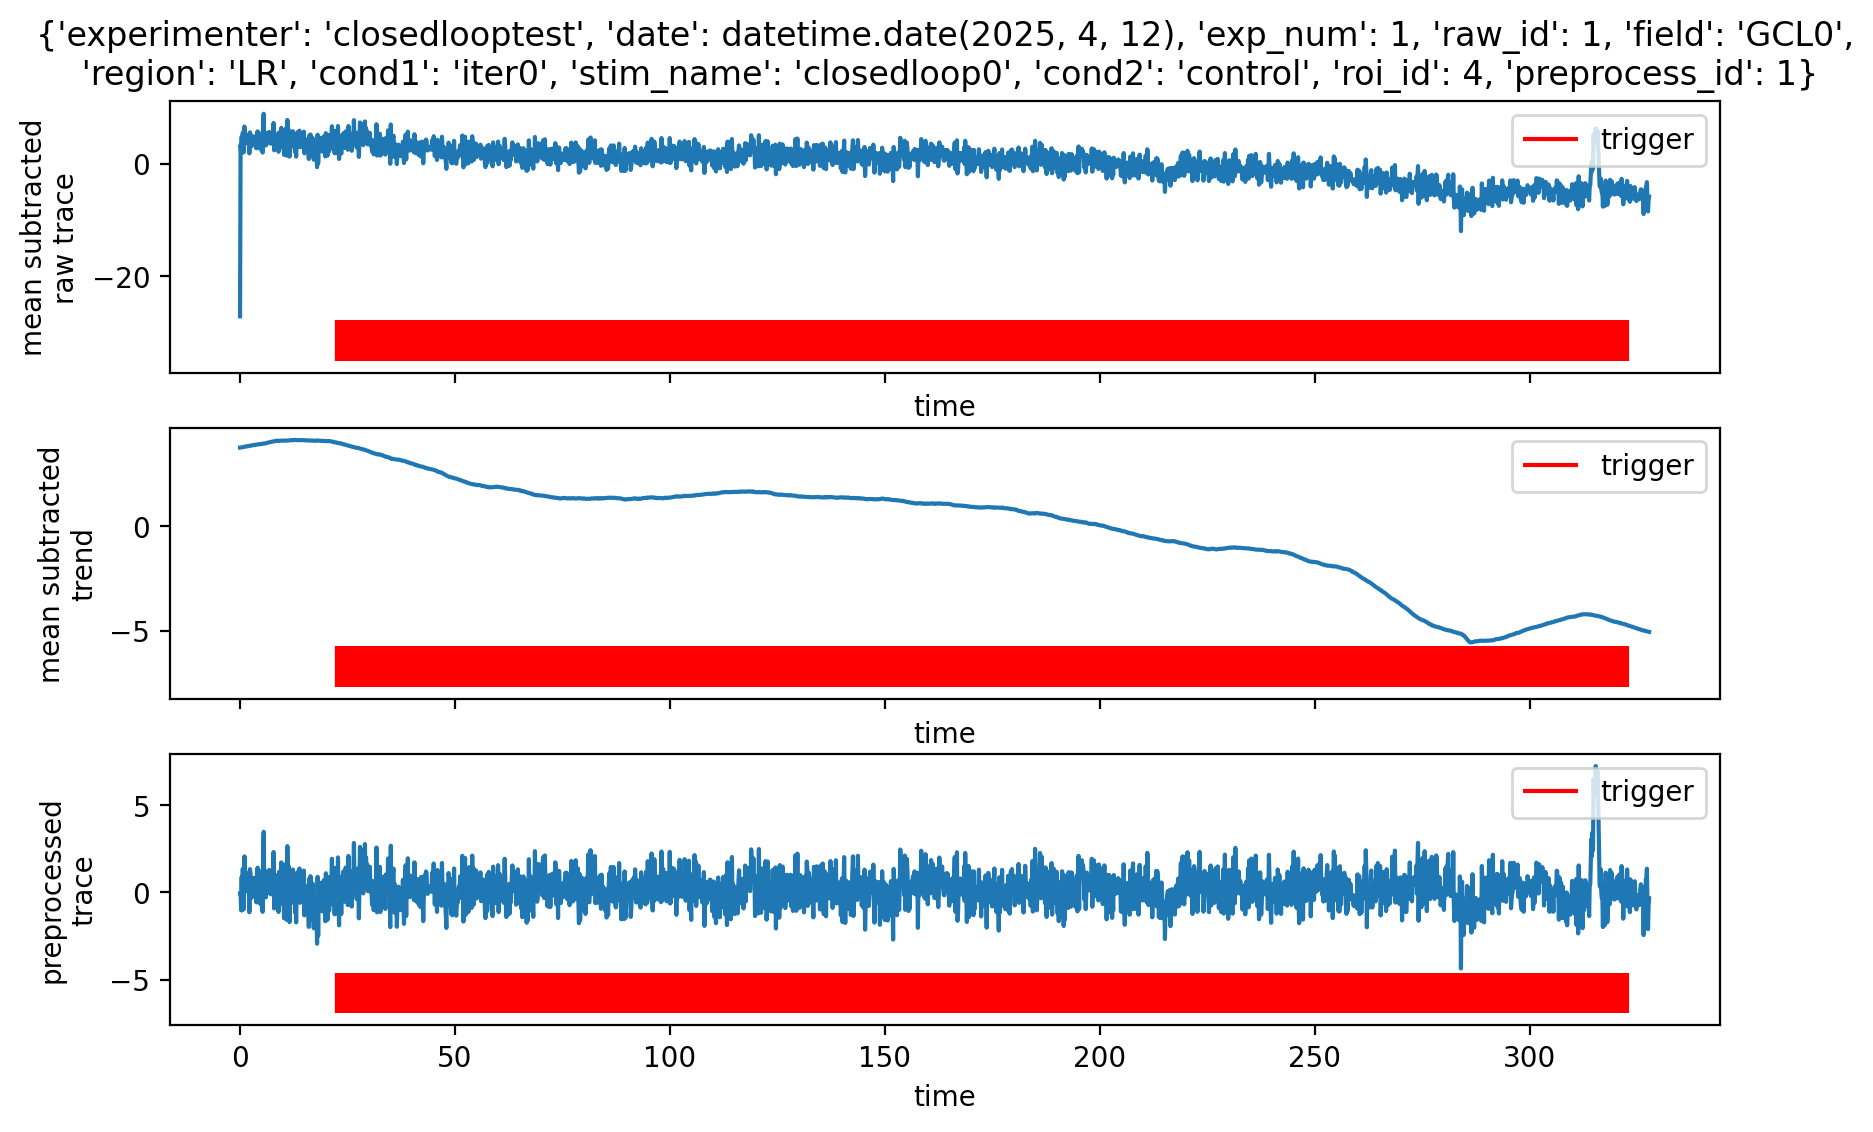

In [51]:
1 == 1 # type: ignore
PreprocessTraces().plot1()

In [45]:
Snippets().populate(processes=20, display_progress=True)
Snippets()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,snippets array of snippets (time x repetitions),"snippets_t0 array of snippet start times (repetitions, )",snippets_dt,triggertimes_snippets snippeted triggertimes (ntrigger_rep x repetitions),droppedlastrep_flag Was the last repetition incomplete and therefore dropped?


## data loading

In [ ]:
iter_key = dict(cond1=f'iter{0}')

pp_trace, smoothed_trace = (PreprocessTraces() & iter_key).fetch("pp_trace", "smoothed_trace")
trace = (Traces() & iter_key).fetch("trace")

# assume these values are the same for each field
triggertimes = (Presentation() & iter_key & dict(roi_id=1)).fetch1("triggertimes") 
trace_t0, trace_dt = (Traces() & iter_key & dict(roi_id=1)).fetch1("trace_t0", "trace_dt")
pp_trace_t0, pp_trace_dt = (PreprocessTraces() & iter_key & dict(roi_id=1) ).fetch1("pp_trace_t0", "pp_trace_dt")

# reshape and tests
pp_trace = np.concatenate(pp_trace).reshape(pp_trace.shape[0], -1)
smoothed_trace = np.concatenate(smoothed_trace).reshape(smoothed_trace.shape[0], -1)
trace = np.concatenate(trace).reshape(trace.shape[0], -1)

trace_times = np.arange(trace[1].size) * trace_dt + pp_trace_t0
pp_trace_times = np.arange(pp_trace[1].size) * pp_trace_dt + pp_trace_t0

## generate train and test split 

### for stimulus 


In [ ]:

stim_path = '/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/stimuli/original/noise.h5'

with h5py.File(stim_path, "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)


# unittests
assert stimulus_shape[1:] == noise_stimulus.shape[1:], f"stimulus shape {stimulus_shape} does not match noise_stimulus shape {noise_stimulus.shape} in spatial dimensions"
assert noise_stimulus.shape[0] % stimulus_shape[0] == 0 , f" noise_stimulus shape {noise_stimulus.shape} in temporal dimension not divisible by {stimulus_shape[0]}"


### for response 

In [ ]:

test_fracting = 0.2

# unittest
assert noise_stimulus.shape[0] * test_fracting % stimulus_shape[0] == 0 , f"Test stimulus shape {noise_stimulus.shape[0] * test_fracting} not divisible by {stimulus_shape[0]}"
assert noise_stimulus.shape[0] * (1 - test_fracting) % stimulus_shape[0] == 0 , f"Train stimulus shape {noise_stimulus.shape[0] * (1 - test_fracting)} not divisible by {stimulus_shape[0]}"


# should set random seed for reproducibility
trigger_idx = np.random.permutation(len(triggertimes))
test_trigger_idx = trigger_idx[:int(len(trigger_idx) * test_fracting)]
train_trigger_idx = trigger_idx[int(len(trigger_idx) * test_fracting):]

# the lower bound number of calcium recording points during one stimulus
trigger_dt = np.mean(np.diff(triggertimes)) # BETTER: divide nr of ca by number of triggers 
lower_bound_n_datapoints = int(trigger_dt / pp_trace_dt) 

# sample data at selected indices and take lower bound number of points
train_triggertimes = triggertimes[train_trigger_idx]
test_triggertimes = triggertimes[test_trigger_idx]

train_response = []
for t in train_triggertimes:
    idx = np.argmin(np.abs(trace_times - t))
    train_response.append(pp_trace[:, idx:idx + lower_bound_n_datapoints])
train_response = np.concatenate(train_response, axis=1)

test_response = []
for t in test_triggertimes:
    idx = np.argmin(np.abs(trace_times - t))
    test_response.append(pp_trace[:, idx:idx + lower_bound_n_datapoints])
test_response = np.concatenate(test_response, axis=1)



In [94]:
train_stimulus = noise_stimulus[train_trigger_idx][np.newaxis, ...]
test_stimulus = noise_stimulus[test_trigger_idx][np.newaxis, ...]
print("train_stimulus.shape:", train_stimulus.shape)
print("test_stimulus.shape:", test_stimulus.shape)

train_stimulus.shape: (1, 1200, 20, 15)
test_stimulus.shape: (1, 300, 20, 15)


##  MovieTrainTestSplit and ResponsesTrainTestSplit instances 

In [95]:
train_stim_mean = train_stimulus.mean()
train_stim_std = train_stimulus.std()

norm_train_stimulus = (train_stimulus - train_stim_mean) / train_stim_std
norm_test_stimulus = (test_stimulus - train_stim_mean) / train_stim_std

In [97]:
single_stimulus = MoviesTrainTestSplit(
    train=norm_train_stimulus,
    test=norm_test_stimulus,
    stim_id="whitenoise",
    norm_mean=train_stim_mean,
    norm_std=train_stim_std,
)

single_response = ResponsesTrainTestSplit(
    train=train_response,
    test=test_response,
    stim_id="whitenoise",
)

## data loaders from TrainTestSplit objects

In [123]:
stimuli = {"iter0": single_stimulus}
responses = {"iter0": single_response}
dataloaders = multiple_movies_dataloaders(neuron_data_dictionary=responses, 
                                          movies_dictionary=stimuli,
                                          clip_length=stimulus_shape[0],
                                          train_chunk_size=stimulus_shape[0], # what is training chunk size used for? 
                                          batch_size = 16,
                                          )

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

## model 

In [124]:
data_info = compute_data_info(neuron_data_dictionary=responses, movies_dictionary=stimuli)

# Display the data info
pp.pprint(data_info)

{   'input_shape': (1, 20, 15),
    'movie_norm_dict': {   'iter0': {   'norm_mean': np.float64(0.5009666666666667),
                                        'norm_std': np.float64(0.4999990655546823)}},
    'n_neurons_dict': {'iter0': 101},
    'sessions_kwargs': {'iter0': {}}}


In [125]:
model = CoreReadout(
    in_shape=(1, 100, 20, 15),  # Note that data_info does not include time, we add a dummy time dimension here.
    hidden_channels=[32, 64], # Number of filters for each convolutional layer
    temporal_kernel_sizes=[5, 5], # Kernel size for temporal convolutions for each convolutional layer
    spatial_kernel_sizes=[3, 3], # Kernel size for spatial convolutions for each convolutional layer
    n_neurons_dict=data_info["n_neurons_dict"],
)

/gpfs01/euler/User/ssuhai/GitRepos/open-retina/openretina/models/core_readout.py:189: UserWarning: Cutting frames from the core output can lead to unexpected results if the input is not padded.self._cut_first_n_frames=30, input_padding=False. Double check the core output shape.
  core = SimpleCoreWrapper(
2025-04-23 13:19:51,844 - INFO - in_shape_readout=torch.Size([64, 66, 18, 13])


In [126]:
train_loader = LongCycler(dataloaders["train"])
val_loader = ShortCycler(dataloaders["validation"])
test_loader = ShortCycler(dataloaders["test"])

In [128]:
trainer = lightning.Trainer(max_epochs=50) # Extra trainer hyperparameters would go here trainer.fit(model, train_loader, val_loader)
trainer.fit(model, train_loader, val_loader)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
[2025-04-23 13:23:06,818][WARNING]: MySQL server has gone away. Reconnecting to the server.
2025-04-23 13:23:06,818 - WARNING - MySQL server has gone away. Reconnecting to the server.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                        | Params | Mode 
-------------------------------------------------------------------------
0 | core             | SimpleCoreWrapper           | 23.2 K | train
1 | readout          | MultiGaussianReadoutWrapper | 7.0 K  | train
2 | loss             | PoissonLoss3d               | 0      | train
3 | correlation_loss | CorrelationLoss3d           | 0      | train
-------------------------------------------------------------------------
30.1 K    Trainable params
0         Non-trainable params
30.1 K    Total params
0.121     Total estimated model params size (MB)
18        Modules in train mode
0      

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
